Deep Learning Model Comparison
## VGG16 vs VGG19 vs EfficientNetB0 — Chest X-Ray Pneumonia Classification
**Course:** Deep Learning | **Dataset:** Kermany et al. (Kaggle) | **Seed:** 42

| Phase | Description |
|---|---|
| 1 | Setup, seeds, GPU check |
| 2 | Dataset download & EDA |
| 3 | Preprocessing & augmentation |
| 4 | Model definitions |
| 5 | Training (transfer learning + fine-tuning) |
| 6 | Evaluation & comparison graphs |
| 7 | Medical analysis (Grad-CAM, sensitivity/specificity) |
| 8 | Export results |

In [1]:
!pip install -q kaggle visualkeras tensorflow matplotlib seaborn scikit-learn opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 58.8 MB/s eta 0:00:00


In [35]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [39]:
import os, random, warnings
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


warnings.filterwarnings('ignore')

# ── Global Config ─────────────────────────────────────────
SEED        = 42
IMG_SIZE    = (224, 224)
IMG_SHAPE   = (224, 224, 3)
BATCH_SIZE  = 32
EPOCHS_FE   = 5      # feature extraction (frozen base)
EPOCHS_FT   = 20     # fine-tuning (unfrozen base)
LR_FE       = 1e-3
LR_FT       = 1e-5
MODELS_LIST = ["VGG16", "VGG19", "EfficientNetB0"]

BASE_DIR = "/content/drive/MyDrive/DeepLearningProject"
SAVE_DIR = f"{BASE_DIR}/saved_models"
FIG_DIR  = f"{BASE_DIR}/figures"

# SAVE_DIR    = "/content/saved_models"
# FIG_DIR     = "/content/figures"
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(FIG_DIR,  exist_ok=True)
# ──────────────────────────────────────────────────────────

# Fix all seeds for reproducibility
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# GPU check
gpus = tf.config.list_physical_devices('GPU')
print(f"✅ TensorFlow {tf.__version__}")
print(f"✅ GPU available: {len(gpus) > 0} → {gpus if gpus else 'Using CPU'}")

✅ TensorFlow 2.20.0
✅ GPU available: True → [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [40]:
!pip install -q kagglehub

import kagglehub
dataset_path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Downloaded to:", dataset_path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Downloaded to: /kaggle/input/chest-xray-pneumonia


In [5]:
import os
from pathlib import Path

dataset_path = Path(dataset_path)
print(list(dataset_path.iterdir())[:10])

def find_split_dir(root, split_name):
    for p in root.rglob(split_name):
        if p.is_dir() and (p / "NORMAL").exists() and (p / "PNEUMONIA").exists():
            return p
    return None

TRAIN_DIR = find_split_dir(dataset_path, "train")
VAL_DIR   = find_split_dir(dataset_path, "val")
TEST_DIR  = find_split_dir(dataset_path, "test")

print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)
print("TEST_DIR:", TEST_DIR)

[PosixPath('/kaggle/input/chest-xray-pneumonia/chest_xray')]
TRAIN_DIR: /kaggle/input/chest-xray-pneumonia/chest_xray/train
VAL_DIR: /kaggle/input/chest-xray-pneumonia/chest_xray/val
TEST_DIR: /kaggle/input/chest-xray-pneumonia/chest_xray/test


In [6]:
from pathlib import Path

def count_images(split_dir):
    counts = {}
    for cls in split_dir.iterdir():
        if cls.is_dir():
            counts[cls.name] = len(list(cls.glob("*.jpeg")) + list(cls.glob("*.jpg")) + list(cls.glob("*.png")))
    return counts

train_counts = count_images(TRAIN_DIR)
val_counts = count_images(VAL_DIR)
test_counts = count_images(TEST_DIR)

print(f"{'Split':<10} {'NORMAL':>10} {'PNEUMONIA':>12} {'TOTAL':>8}")
for split, counts in [("Train", train_counts), ("Val", val_counts), ("Test", test_counts)]:
    n = counts.get("NORMAL", 0)
    p = counts.get("PNEUMONIA", 0)
    print(f"{split:<10} {n:>10} {p:>12} {n+p:>8}")

Split          NORMAL    PNEUMONIA    TOTAL
Train            1341         3875     5216
Val                 8            8       16
Test              234          390      624


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Dataset Class Distribution", fontsize=16, fontweight="bold")
colors = ["#4CAF50", "#F44336"]
splits = [("Train", train_counts), ("Validation", val_counts), ("Test", test_counts)]

for ax, (split_name, counts) in zip(axes, splits):
    classes = list(counts.keys())
    values = list(counts.values())
    bars = ax.bar(classes, values, color=colors, edgecolor="black", width=0.5)
    ax.set_title(split_name, fontweight="bold")
    ax.set_ylabel("Image Count")
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(val),
                ha="center", va="bottom", fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

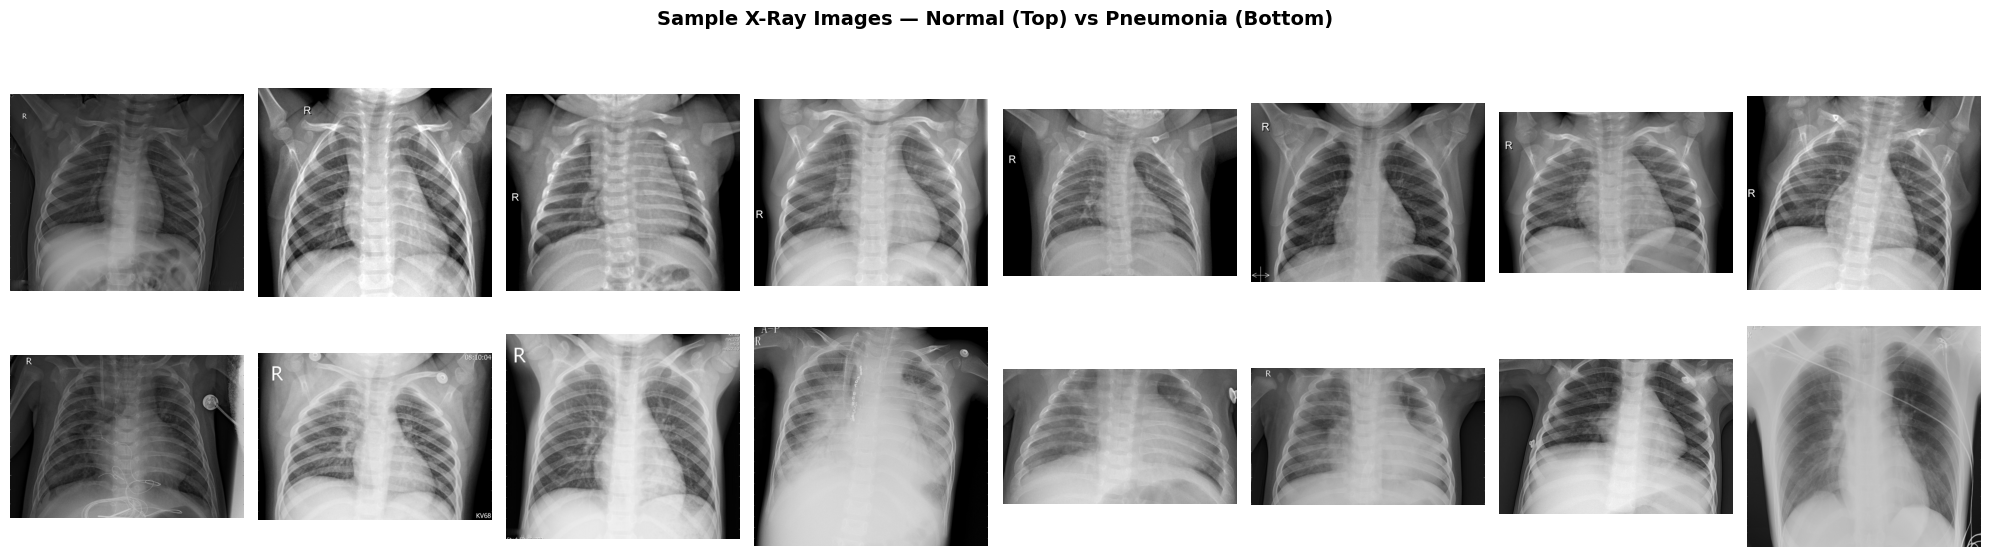

In [10]:
import cv2

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle("Sample X-Ray Images — Normal (Top) vs Pneumonia (Bottom)", fontsize=14, fontweight="bold")

for cls in ["NORMAL", "PNEUMONIA"]:
    cls_dir = TRAIN_DIR / cls
    imgs = list(cls_dir.glob("*.jpeg"))[:8]
    row = 0 if cls == "NORMAL" else 1
    for i, img_path in enumerate(imgs):
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        axes[row][i].imshow(img, cmap="gray")
        axes[row][i].axis("off")
        if i == 0:
            axes[row][i].set_ylabel(cls, fontsize=11, fontweight="bold", rotation=0, labelpad=60, va="center")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/sample_images.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

eval_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary", seed=SEED)
val_gen   = eval_datagen.flow_from_directory(VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary", seed=SEED, shuffle=False)
test_gen  = eval_datagen.flow_from_directory(TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary", seed=SEED, shuffle=False)

print(train_gen.class_indices)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
{'NORMAL': 0, 'PNEUMONIA': 1}


In [12]:
from tensorflow.keras.applications import VGG16, VGG19, EfficientNetB0
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.optimizers import Adam

def build_model(model_name):
    base_map = {"VGG16": VGG16, "VGG19": VGG19, "EfficientNetB0": EfficientNetB0}
    base_fn = base_map[model_name]
    base = base_fn(weights="imagenet", include_top=False, input_shape=IMG_SHAPE)
    base.trainable = False

    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = Model(base.input, out, name=model_name)
    model.compile(
        optimizer=Adam(learning_rate=LR_FE),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc"), tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
    )
    return model, base

In [13]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger

def get_callbacks(model_name, phase):
    return [
        ModelCheckpoint(f"{SAVE_DIR}/{model_name}_best_{phase}.keras", monitor="val_auc", mode="max", save_best_only=True, verbose=0),
        EarlyStopping(monitor="val_auc", patience=5, mode="max", restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1),
        CSVLogger(f"{SAVE_DIR}/{model_name}_{phase}_log.csv")
    ]

models_dict, histories_fe, histories_ft = {}, {}, {}

for name in MODELS_LIST:
    model, base = build_model(name)
    models_dict[name] = {"model": model, "base": base}
    print(f"Training {name}...")
    h = model.fit(train_gen, epochs=EPOCHS_FE, validation_data=val_gen, callbacks=get_callbacks(name, "fe"), verbose=1)
    histories_fe[name] = h.history

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Training VGG16...
Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 168s 918ms/step - accuracy: 0.9078 - auc: 0.9585 - loss: 0.2706 - precision: 0.9385 - recall: 0.9373 - val_accuracy: 0.5625 - val_auc: 0.9141 - val_loss: 0.7193 - val_precision: 0.5333 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 117s 720ms/step - accuracy: 0.9339 - auc: 0.9767 - loss: 0.2063 - precision: 0.9587 - recall: 0.9520 - val_accuracy: 0.6875 - val_auc: 0.9609 - val_loss: 0.6518 - val_precision: 0.6154 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 115s 706ms/step - accuracy: 0.9433 - auc: 0.9819 - loss: 0.1861 - precision: 0.9647 - recall: 0.9587 - val_accuracy: 0.6875 - val_auc: 0.9531 - val_loss: 0.6867 - val_precision: 0.6154 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 116s 712ms/step - accuracy: 0.9456 - auc: 0.9838 - loss: 0.1782 - precision: 0.9643 -

In [14]:
for name in MODELS_LIST:
    print(f"Fine-tuning {name}...")
    model = models_dict[name]["model"]
    base = models_dict[name]["base"]
    base.trainable = True
    model.compile(
        optimizer=Adam(learning_rate=LR_FT),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc"), tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
    )
    h = model.fit(train_gen, epochs=EPOCHS_FT, validation_data=val_gen, callbacks=get_callbacks(name, "ft"), verbose=1)
    histories_ft[name] = h.history

Fine-tuning VGG16...
Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 194s 850ms/step - accuracy: 0.9555 - auc: 0.9873 - loss: 0.1600 - precision: 0.9723 - recall: 0.9677 - val_accuracy: 0.9375 - val_auc: 0.9844 - val_loss: 0.2735 - val_precision: 1.0000 - val_recall: 0.8750 - learning_rate: 1.0000e-05
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 137s 836ms/step - accuracy: 0.9701 - auc: 0.9922 - loss: 0.1271 - precision: 0.9821 - recall: 0.9775 - val_accuracy: 0.8125 - val_auc: 0.9844 - val_loss: 0.4568 - val_precision: 0.7273 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 138s 840ms/step - accuracy: 0.9684 - auc: 0.9920 - loss: 0.1293 - precision: 0.9808 - recall: 0.9765 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.1797 - val_precision: 0.8889 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 136s 834ms/step - accuracy: 0.9774 - auc: 0.9966 - loss: 0.1003 - precision: 0.9883 - recall: 0.9812 - val_accuracy: 

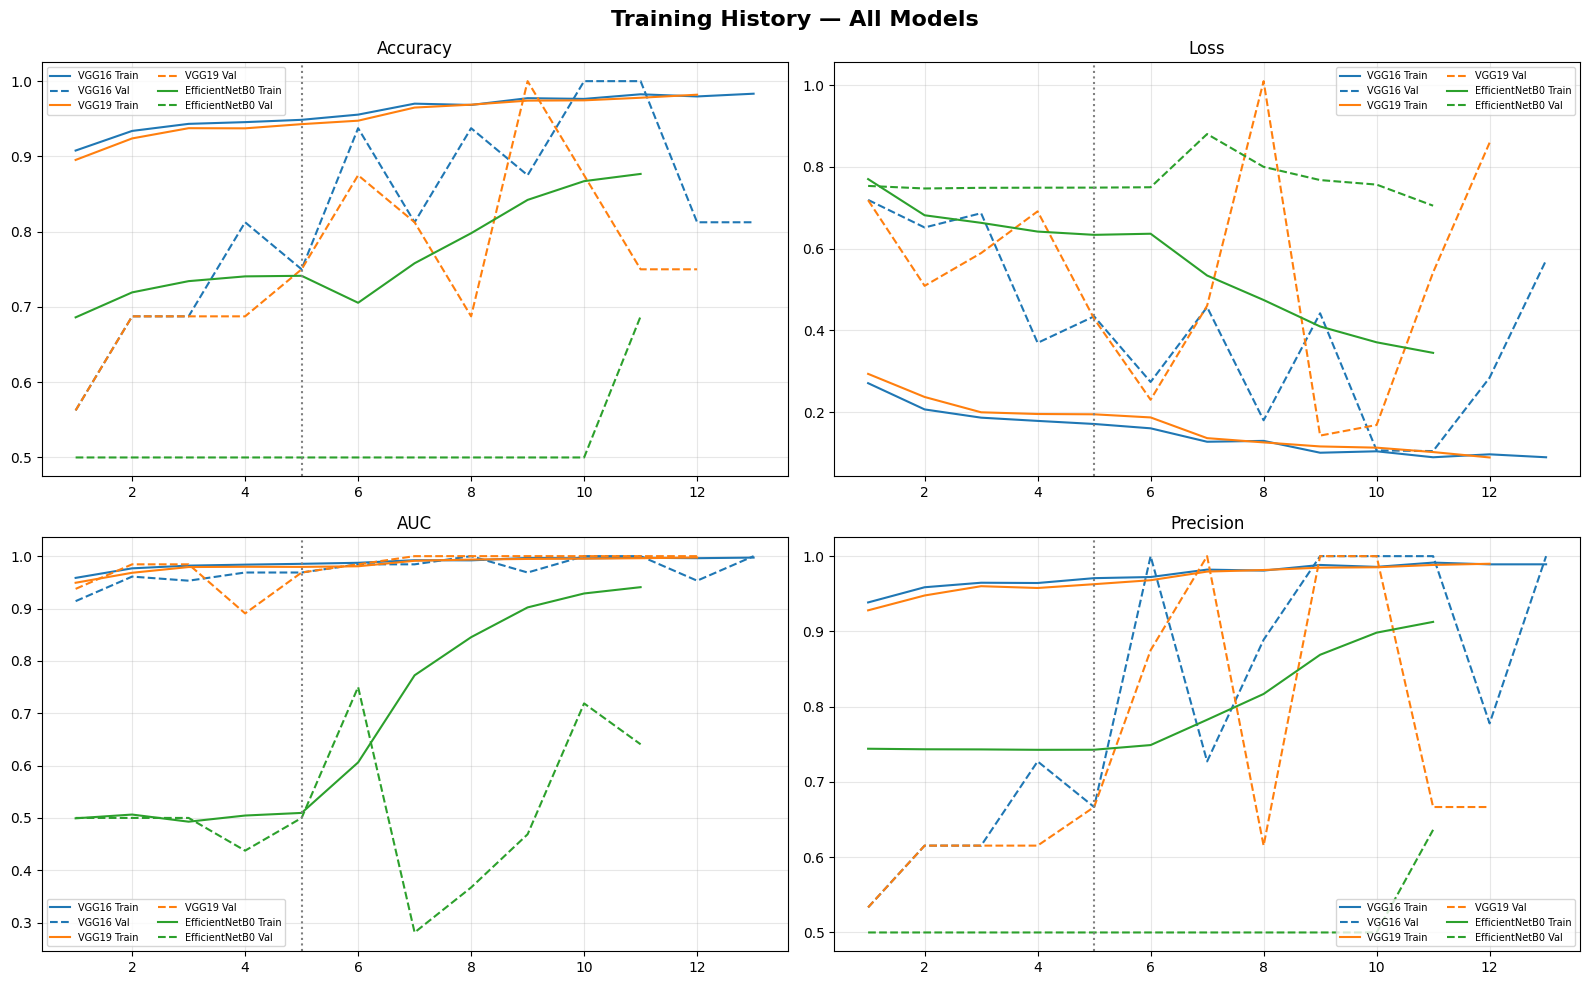

In [15]:
def merge_history(fe, ft, key):
    return fe.get(key, []) + ft.get(key, [])

COLORS = {"VGG16": "#1f77b4", "VGG19": "#ff7f0e", "EfficientNetB0": "#2ca02c"}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Training History — All Models", fontsize=16, fontweight="bold")

metrics = [
    ("accuracy", "val_accuracy", "Accuracy", axes[0][0]),
    ("loss", "val_loss", "Loss", axes[0][1]),
    ("auc", "val_auc", "AUC", axes[1][0]),
    ("precision", "val_precision", "Precision", axes[1][1]),
]

for tr_key, val_key, title, ax in metrics:
    for name in MODELS_LIST:
        tr = merge_history(histories_fe[name], histories_ft[name], tr_key)
        vl = merge_history(histories_fe[name], histories_ft[name], val_key)
        epochs = range(1, len(tr) + 1)
        ax.plot(epochs, tr, label=f"{name} Train", color=COLORS[name])
        ax.plot(epochs, vl, label=f"{name} Val", color=COLORS[name], linestyle="--")
    ax.axvline(EPOCHS_FE, color="gray", linestyle=":")
    ax.set_title(title)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

results = {}

for name in MODELS_LIST:
    model = models_dict[name]["model"]
    test_gen.reset()
    y_prob = model.predict(test_gen, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    y_true = test_gen.classes

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    report = classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"], output_dict=True)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    results[name] = {
        "cm": cm, "report": report, "fpr": fpr, "tpr": tpr, "auc": roc_auc,
        "accuracy": report["accuracy"],
        "sensitivity": tp / (tp + fn),
        "specificity": tn / (tn + fp),
        "precision": report["PNEUMONIA"]["precision"],
        "recall": report["PNEUMONIA"]["recall"],
        "f1": report["PNEUMONIA"]["f1-score"]
    }

    print(name, results[name]["accuracy"], results[name]["sensitivity"], results[name]["specificity"], roc_auc)

VGG16 0.8974358974358975 0.982051282051282 0.7564102564102564 0.9680254218715757
VGG19 0.844551282051282 0.7794871794871795 0.9529914529914529 0.9689349112426036
EfficientNetB0 0.625 1.0 0.0 0.6583333333333333


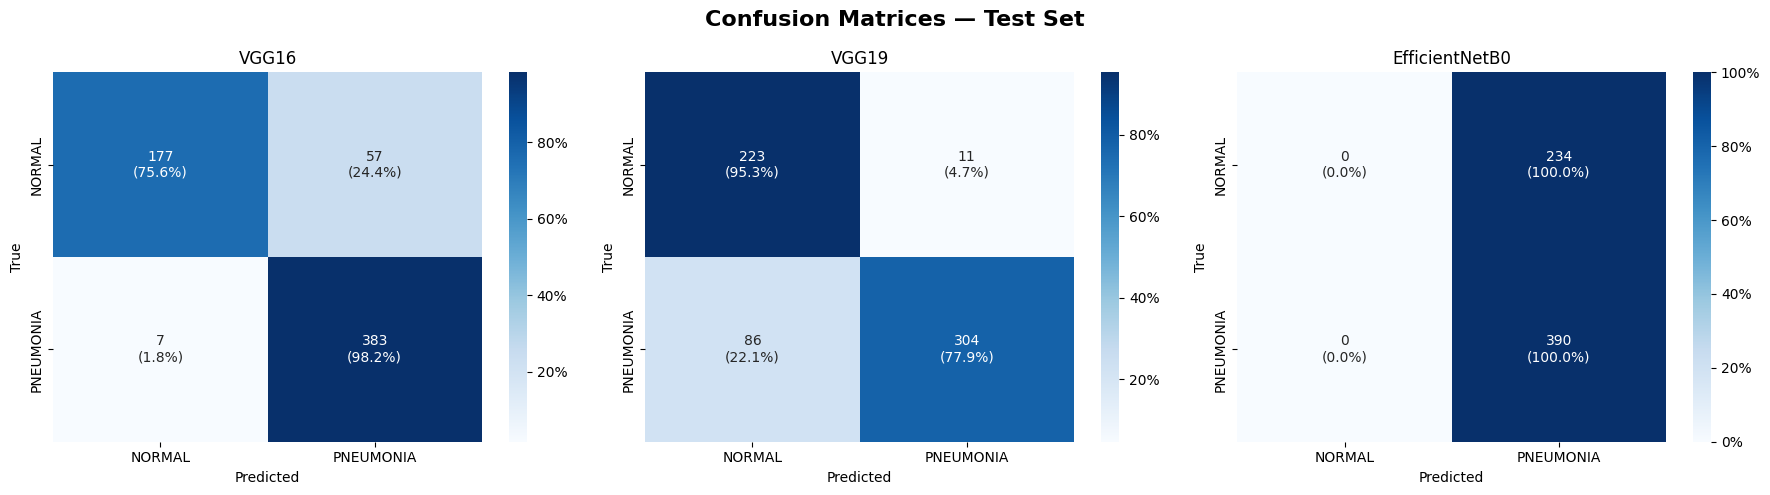

In [18]:
import seaborn as sns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices — Test Set", fontsize=16, fontweight="bold")

for ax, name in zip(axes, MODELS_LIST):
    cm = results[name]["cm"]
    cm_pct = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100
    annot = np.array([[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)])
    sns.heatmap(cm_pct, annot=annot, fmt="", cmap="Blues", xticklabels=["NORMAL", "PNEUMONIA"], yticklabels=["NORMAL", "PNEUMONIA"], ax=ax, cbar_kws={"format": "%.0f%%"})
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

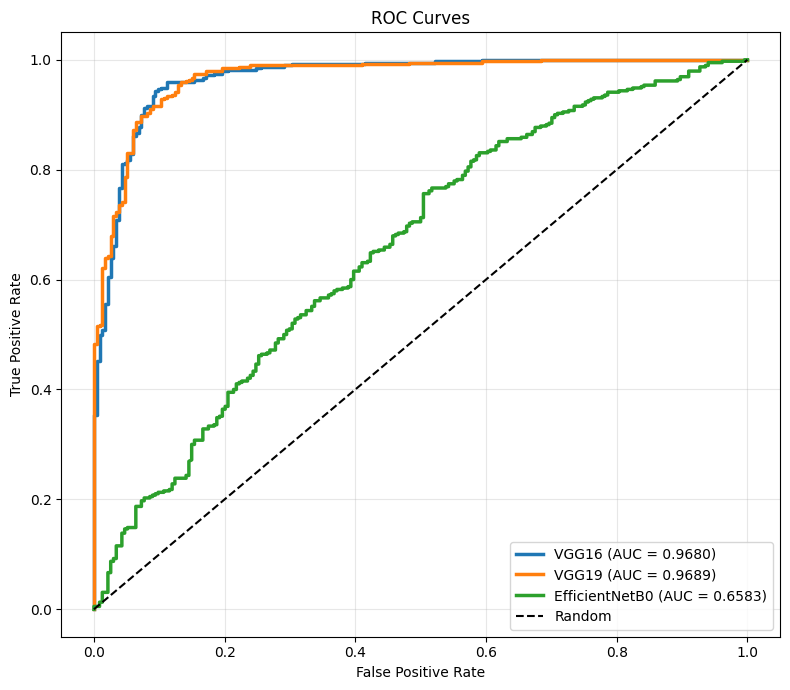

In [19]:
fig, ax = plt.subplots(figsize=(8, 7))
for name in MODELS_LIST:
    r = results[name]
    ax.plot(r["fpr"], r["tpr"], lw=2.5, label=f"{name} (AUC = {r['auc']:.4f})", color=COLORS[name])

ax.plot([0, 1], [0, 1], "k--", label="Random")
ax.set_title("ROC Curves")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

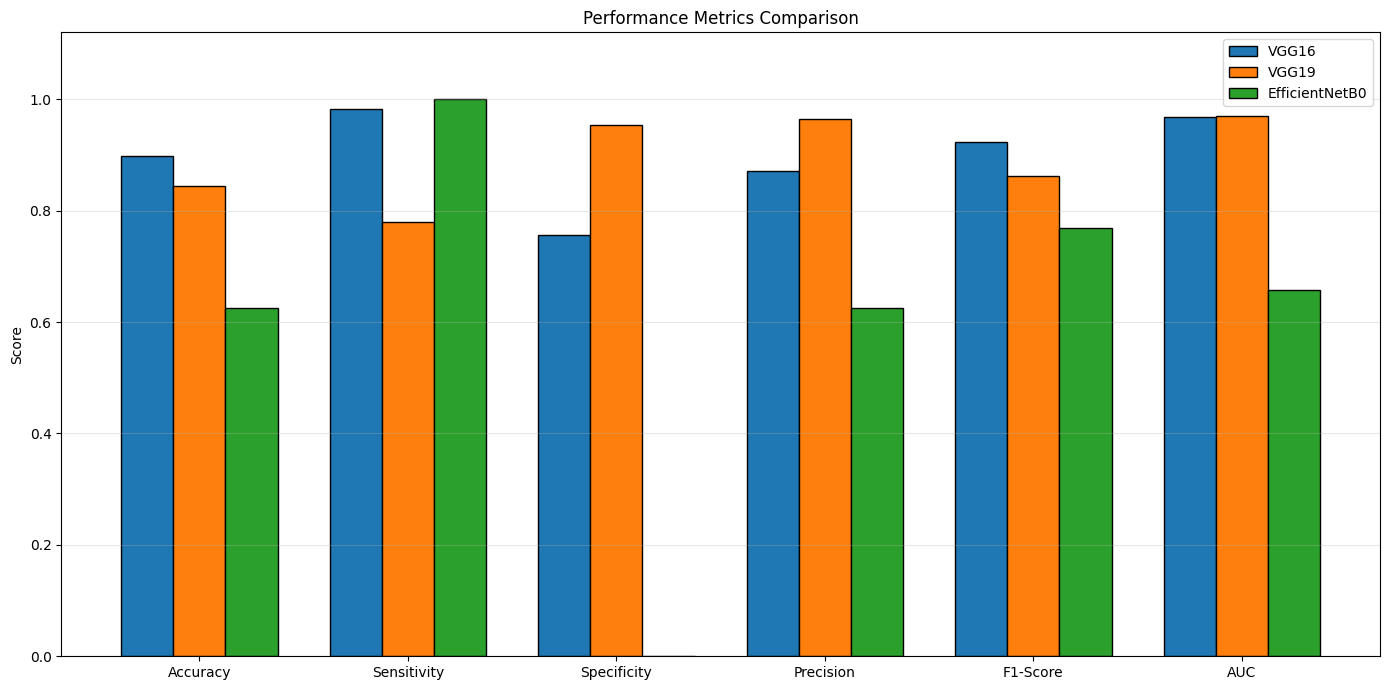

In [20]:
metrics_to_plot = {"Accuracy": "accuracy", "Sensitivity": "sensitivity", "Specificity": "specificity", "Precision": "precision", "F1-Score": "f1", "AUC": "auc"}

x = np.arange(len(metrics_to_plot))
width = 0.25
fig, ax = plt.subplots(figsize=(14, 7))

for i, name in enumerate(MODELS_LIST):
    vals = [results[name][k] for k in metrics_to_plot.values()]
    ax.bar(x + i * width, vals, width, label=name, color=list(COLORS.values())[i], edgecolor="black")

ax.set_xticks(x + width)
ax.set_xticklabels(list(metrics_to_plot.keys()))
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Performance Metrics Comparison")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

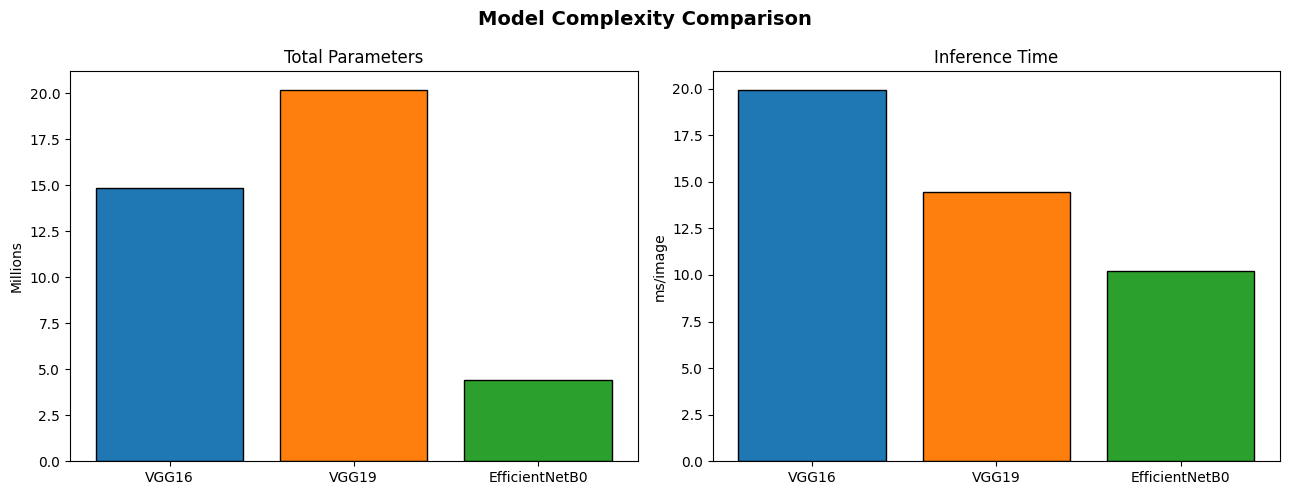

In [22]:
import time
param_counts, inference_times = {}, {}

for name in MODELS_LIST:
    m = models_dict[name]["model"]
    total_params = m.count_params()
    trainable = sum(np.prod(v.shape) for v in m.trainable_variables)
    param_counts[name] = {"total": total_params / 1e6, "trainable": trainable / 1e6}

    dummy = np.random.rand(100, *IMG_SHAPE).astype(np.float32)
    _ = m.predict(dummy[:1], verbose=0)
    t0 = time.time()
    _ = m.predict(dummy, batch_size=32, verbose=0)
    inference_times[name] = (time.time() - t0) * 10

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Model Complexity Comparison", fontsize=14, fontweight="bold")

names = MODELS_LIST
total_p = [param_counts[n]["total"] for n in names]
axes[0].bar(names, total_p, color=list(COLORS.values()), edgecolor="black")
axes[0].set_title("Total Parameters")
axes[0].set_ylabel("Millions")

inf_t = [inference_times[n] for n in names]
axes[1].bar(names, inf_t, color=list(COLORS.values()), edgecolor="black")
axes[1].set_title("Inference Time")
axes[1].set_ylabel("ms/image")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/model_complexity.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
import cv2
from tensorflow.keras.models import Model

def get_gradcam_heatmap(model, img_array, last_conv_layer_name):
    grad_model = Model(inputs=model.input, outputs=[model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        class_score = preds[:, 0]
    grads = tape.gradient(class_score, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_out[0] @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap).numpy()
    heatmap = np.maximum(heatmap, 0)
    return heatmap / (heatmap.max() + 1e-8)

LAST_CONV = {"VGG16": "block5_conv3", "VGG19": "block5_conv4", "EfficientNetB0": "top_conv"}

In [24]:
pneumonia_imgs = list((TEST_DIR / "PNEUMONIA").glob("*.jpeg"))[:3]
normal_imgs = list((TEST_DIR / "NORMAL").glob("*.jpeg"))[:2]
sample_imgs = pneumonia_imgs + normal_imgs
sample_labels = ["PNEUMONIA"] * 3 + ["NORMAL"] * 2

fig, axes = plt.subplots(len(MODELS_LIST), len(sample_imgs), figsize=(20, 13))
fig.suptitle("Grad-CAM Heatmaps", fontsize=15, fontweight="bold")

for row, model_name in enumerate(MODELS_LIST):
    m = models_dict[model_name]["model"]
    for col, (img_path, true_label) in enumerate(zip(sample_imgs, sample_labels)):
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
        img_arr = tf.keras.preprocessing.image.img_to_array(img) / 255.0
        img_input = np.expand_dims(img_arr, axis=0)
        prob = m.predict(img_input, verbose=0)[0][0]
        pred_label = "PNEUMONIA" if prob >= 0.5 else "NORMAL"

        heatmap = get_gradcam_heatmap(m, img_input, LAST_CONV[model_name])
        orig = cv2.imread(str(img_path))
        orig = cv2.resize(orig, IMG_SIZE)
        heat = cv2.resize(heatmap, IMG_SIZE)
        heat = np.uint8(255 * heat)
        heat = cv2.applyColorMap(heat, cv2.COLORMAP_JET)
        overlay = cv2.addWeighted(orig, 0.55, heat, 0.45, 0)
        overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

        axes[row][col].imshow(overlay)
        axes[row][col].set_title(f"True: {true_label}\nPred: {pred_label} ({prob:.2f})", fontsize=9)
        axes[row][col].axis("off")
    axes[row][0].set_ylabel(model_name, fontsize=11, fontweight="bold", rotation=90, labelpad=10)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/gradcam.png", dpi=150, bbox_inches="tight")
plt.show()

In [28]:
import pandas as pd


summary = pd.DataFrame({
    "Model": MODELS_LIST,
    "Accuracy": [results[n]["accuracy"] for n in MODELS_LIST],
    "Sensitivity": [results[n]["sensitivity"] for n in MODELS_LIST],
    "Specificity": [results[n]["specificity"] for n in MODELS_LIST],
    "Precision": [results[n]["precision"] for n in MODELS_LIST],
    "F1-Score": [results[n]["f1"] for n in MODELS_LIST],
    "AUC": [results[n]["auc"] for n in MODELS_LIST],
    "Params_M": [param_counts[n]["total"] for n in MODELS_LIST],
    "Inference_ms": [inference_times[n] for n in MODELS_LIST]
})
summary.to_csv(f"{SAVE_DIR}/results_summary.csv", index=False)
summary

,Model,Accuracy,Sensitivity,Specificity,Precision,F1-Score,AUC,Params_M,Inference_ms
0,VGG16,0.897436,0.982051,0.756410,0.870455,0.922892,0.968025,14.864577,19.928839
1,VGG19,0.844551,0.779487,0.952991,0.965079,0.862411,0.968935,20.174273,14.472935
2,EfficientNetB0,0.625000,1.000000,0.000000,0.625000,0.769231,0.658333,4.399140,10.233514


In [33]:
for name in MODELS_LIST:
    models_dict[name]["model"].save(f"{SAVE_DIR}/{name}_final.keras")

import shutil
shutil.make_archive("/content/project_figures", "zip", FIG_DIR)
print("Saved all models and figures.")

Saved all models and figures.
